In [4]:
import pandas as pd
import matplotlib.pyplot as plt

In [16]:
df = pd.read_csv("preply_tutors_arabic.csv")
print("Total rows:", len(df))

Total rows: 5844


In [17]:
df.head()

,tutor_id,name,profile_url,country,badge,image_url,online_status,price,lesson_duration,rating,reviews,students,lessons,teaches,speaks,desc_title,desc_body
0,1603742,Batoul K.,https://preply.com/en/tutor/1603742,Türkiye,NaN,https://avatars.preply.com/i/logos/i/logos/ava...,Online,$10,50-min lesson,5.0,9.0,5.0,2274.0,Arabic,"Arabic(Native),, English(Advanced) +1 more","My name is Batul Hanshur, I teach Arabic and t...",My name is Batul Hanshur. I am 22 years old. I...
1,6441235,Huda A.,https://preply.com/en/tutor/6441235,Iraq,Professional,https://avatars.preply.com/i/logos/i/logos/ava...,Online,$18,50-min lesson,5.0,19.0,40.0,1011.0,Arabic,"Arabic(Native),, English(Proficient) +1 more",Learn Arabic in a Fun and Enjoyable Way,"Hi there! My name is Huda, and I'm an Arabic t..."
2,4274325,Ahmed K.,https://preply.com/en/tutor/4274325,"Palestine, State of",Professional,https://avatars.preply.com/i/logos/i/logos/ava...,Online,$21,50-min lesson,4.9,61.0,22.0,2206.0,Arabic,"Arabic(Native),, English(Proficient) +1 more",Speak Arabic Like a NATIVE! .. Palestinian Tut...,"I'm Ahmed, your Palestinian Arabic teacher! Wi..."
3,1802800,Affan M.,https://preply.com/en/tutor/1802800,Pakistan,Professional,https://avatars.preply.com/i/logos/i/logos/ava...,Online,$6,50-min lesson,5.0,35.0,16.0,3195.0,Arabic,"Arabic(Proficient),, English(Advanced) +3 more",Certified Arabic (MSA/Fusha/Classical) & Islam...,"Assalamu Alaikum,I am Affan from Pakistan, a d..."
4,3424492,Nabil H.,https://preply.com/en/tutor/3424492,Lebanon,Professional,https://avatars.preply.com/i/logos/i/logos/ava...,Online,$25,50-min lesson,4.9,34.0,20.0,2645.0,Arabic,"Arabic(Native),, English(Proficient) +2 more",Master Arabic with a Native Lebanese Tutor: Fr...,"Hello! My name is Nabil, a native Arabic speak..."


In [11]:
print("Total rows:", len(df))

Total rows: 545


In [48]:
df["tutor_id"].unique

<bound method Series.unique of 0      6429509
1      6693602
2      3984722
3      2887303
4        64621
        ...   
620    5967171
621    2329586
622    6488520
623    6446542
624    5507003
Name: tutor_id, Length: 625, dtype: int64>

In [49]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 625 entries, 0 to 624
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   tutor_id         625 non-null    int64  
 1   name             625 non-null    str    
 2   profile_url      625 non-null    str    
 3   country          625 non-null    str    
 4   badge            264 non-null    str    
 5   image_url        625 non-null    str    
 6   online_status    625 non-null    str    
 7   price            625 non-null    str    
 8   lesson_duration  625 non-null    str    
 9   rating           373 non-null    float64
 10  reviews          373 non-null    float64
 11  students         319 non-null    float64
 12  lessons          491 non-null    float64
 13  teaches          625 non-null    str    
 14  speaks           625 non-null    str    
 15  desc_title       625 non-null    str    
 16  desc_body        625 non-null    str    
dtypes: float64(4), int64(1), st

In [50]:
df.describe()

,tutor_id,rating,reviews,students,lessons
count,6.250000e+02,373.000000,373.000000,319.000000,491.000000
mean,5.207064e+06,4.896783,22.053619,10.786834,869.851324
std,2.129828e+06,0.442489,42.449810,17.326635,2254.465225
min,2.324500e+04,1.000000,1.000000,1.000000,1.000000
25%,3.837978e+06,5.000000,1.000000,1.000000,6.000000
50%,5.921740e+06,5.000000,5.000000,3.000000,40.000000
75%,6.926840e+06,5.000000,24.000000,12.500000,612.500000
max,7.557676e+06,5.000000,321.000000,105.000000,20487.000000


In [51]:
df.shape

(625, 17)

In [52]:
df["price"].isnull().sum()

np.int64(0)

In [53]:
df["price"].unique()

<StringArray>
[  '$9',  '$11',  '$12',   '$7',  '$18',  '$17',  '$10',   '$4',  '$20',
   '$6',  '$39',   '$5',   '$8',  '$14',  '$15',   '$3',  '$16',  '$13',
  '$25',  '$30',  '$23',  '$19',  '$55',  '$40', '$100',  '$26',  '$22']
Length: 27, dtype: str

In [54]:
df = df.sort_values("online_status", ascending=False).drop_duplicates(subset="tutor_id", keep="first")

In [55]:
duplicates = df[df["tutor_id"].duplicated(keep=False)]
duplicates

,tutor_id,name,profile_url,country,badge,image_url,online_status,price,lesson_duration,rating,reviews,students,lessons,teaches,speaks,desc_title,desc_body


In [56]:
df['price'] = df['price'].str.replace('$', '', regex=False)
df['price'] = pd.to_numeric(df['price'], errors='coerce')

In [57]:
df['students'] = pd.to_numeric(df['students'], errors='coerce')

In [58]:
df['students'].describe()

count    319.000000
mean      10.786834
std       17.326635
min        1.000000
25%        1.000000
50%        3.000000
75%       12.500000
max      105.000000
Name: students, dtype: float64

In [59]:
df['students'].sort_values(ascending=False).head(10)

20     105.0
5       99.0
17      86.0
1       83.0
590     75.0
15      74.0
71      71.0
589     69.0
23      65.0
592     65.0
Name: students, dtype: float64

In [60]:
df['students'].isnull().sum()

np.int64(306)

In [61]:
df['lesson_duration'] = df['lesson_duration'].str.replace(',', '', regex=False)
df['lesson_duration'] = df['lesson_duration'].str.extract('(\d+)')
df['lesson_duration'] = pd.to_numeric(df['lesson_duration'], errors='coerce')

<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:2: SyntaxWarning: invalid escape sequence '\d'
C:\Users\shehe\AppData\Local\Temp\ipykernel_13936\1478307372.py:2: SyntaxWarning: invalid escape sequence '\d'
  df['lesson_duration'] = df['lesson_duration'].str.extract('(\d+)')


In [62]:
df.info()

<class 'pandas.DataFrame'>
Index: 625 entries, 86 to 624
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   tutor_id         625 non-null    int64  
 1   name             625 non-null    str    
 2   profile_url      625 non-null    str    
 3   country          625 non-null    str    
 4   badge            264 non-null    str    
 5   image_url        625 non-null    str    
 6   online_status    625 non-null    str    
 7   price            625 non-null    int64  
 8   lesson_duration  625 non-null    int64  
 9   rating           373 non-null    float64
 10  reviews          373 non-null    float64
 11  students         319 non-null    float64
 12  lessons          491 non-null    float64
 13  teaches          625 non-null    str    
 14  speaks           625 non-null    str    
 15  desc_title       625 non-null    str    
 16  desc_body        625 non-null    str    
dtypes: float64(4), int64(3), str(10

In [63]:
df["lessons"].notnull().sum()

np.int64(491)

In [64]:
df = df.dropna(subset=['price', 'lessons'])

In [65]:
df['price'].describe()

count    491.000000
mean       7.295316
std        7.179645
min        3.000000
25%        3.000000
50%        5.000000
75%        8.000000
max      100.000000
Name: price, dtype: float64

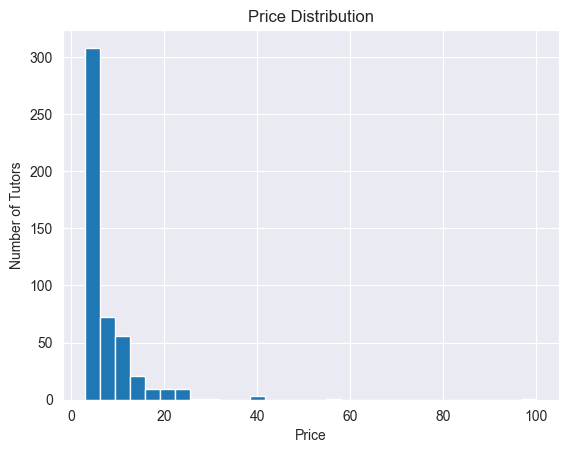

In [66]:
plt.hist(df['price'], bins=30)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Number of Tutors")
plt.show()

In [67]:
df['lessons'].describe()

count      491.000000
mean       869.851324
std       2254.465225
min          1.000000
25%          6.000000
50%         40.000000
75%        612.500000
max      20487.000000
Name: lessons, dtype: float64

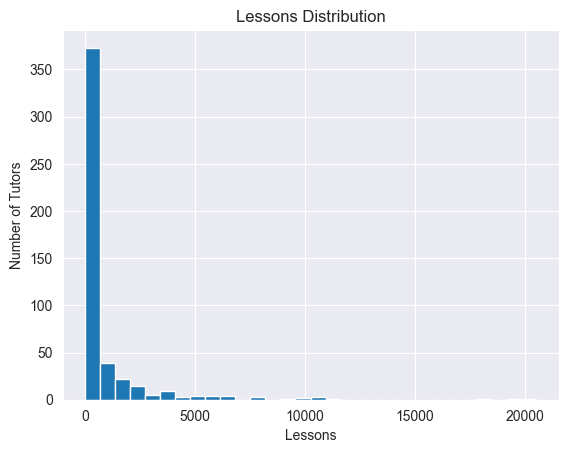

In [68]:
plt.hist(df['lessons'], bins=30)
plt.title("Lessons Distribution")
plt.xlabel("Lessons")
plt.ylabel("Number of Tutors")
plt.show()

In [69]:
price_volume = df.groupby('price')['lessons'].sum().reset_index()

price_volume = price_volume.sort_values('price')
price_volume.head()


,price,lessons
0,3,12934.0
1,4,9708.0
2,5,35972.0
3,6,14615.0
4,7,47706.0


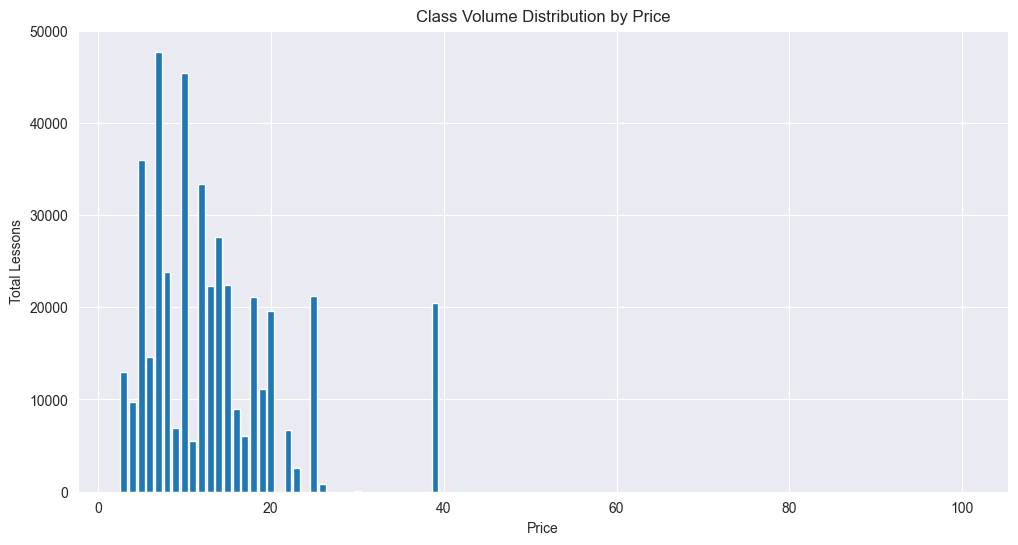

In [70]:
plt.figure(figsize=(12,6))
plt.bar(price_volume['price'], price_volume['lessons'])
plt.xlabel("Price")
plt.ylabel("Total Lessons")
plt.title("Class Volume Distribution by Price")
plt.show()


In [71]:
bins = [0,10,20,30,40,50,100,200]
labels = ['0-10','10-20','20-30','30-40','40-50','50-100','100+']

df['price_bucket'] = pd.cut(df['price'], bins=bins, labels=labels)

bucket_volume = df.groupby('price_bucket')['lessons'].sum().reset_index()


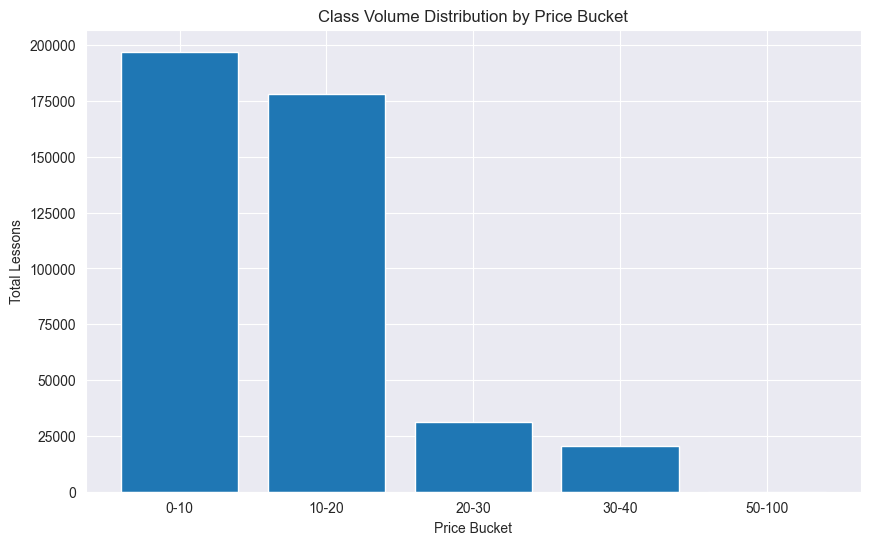

In [72]:
plt.figure(figsize=(10,6))
plt.bar(bucket_volume['price_bucket'], bucket_volume['lessons'])
plt.xlabel("Price Bucket")
plt.ylabel("Total Lessons")
plt.title("Class Volume Distribution by Price Bucket")
plt.show()


In [25]:
df.groupby('price')['lessons'].mean()


price
3        103.472000
4        167.379310
5        356.158416
6        608.958333
7       1325.166667
8        795.700000
9       1151.000000
10      1163.512821
11      1828.000000
12      2384.285714
13      3190.714286
14      6914.000000
15      2246.300000
16      4470.500000
17      2999.500000
18      5271.250000
19     11143.000000
20      2452.000000
22      6654.000000
23      2609.000000
25      2655.000000
26       818.000000
30        71.000000
39     20487.000000
40        10.500000
55         5.000000
100        1.000000
Name: lessons, dtype: float64

In [26]:
df[['price','lessons']].corr()

,price,lessons
price,1.000000,0.319644
lessons,0.319644,1.000000


In [27]:
df['revenue_proxy'] = df['price'] * df['lessons']

df.groupby('price')['revenue_proxy'].sum()


price
3       38802.0
4       38832.0
5      179860.0
6       87690.0
7      333942.0
8      190968.0
9       62154.0
10     453770.0
11      60324.0
12     400560.0
13     290355.0
14     387184.0
15     336945.0
16     143056.0
17     101983.0
18     379530.0
19     211717.0
20     392320.0
22     146388.0
23      60007.0
25     531000.0
26      21268.0
30       2130.0
39     798993.0
40        840.0
55        275.0
100       100.0
Name: revenue_proxy, dtype: float64

In [28]:
# Create revenue proxy
df['revenue'] = df['price'] * df['lessons']

# Group by price
summary = df.groupby('price').agg(
    sum_active_students=('students', 'sum'),
    sum_lessons=('lessons', 'sum'),
    total_revenue=('revenue', 'sum')
).reset_index()

# Sort by price
summary = summary.sort_values('price')

summary.head()


,price,sum_active_students,sum_lessons,total_revenue
0,3,178.0,12934.0,38802.0
1,4,178.0,9708.0,38832.0
2,5,415.0,35972.0,179860.0
3,6,133.0,14615.0,87690.0
4,7,348.0,47706.0,333942.0


In [29]:
grand_total = pd.DataFrame({
    'price': ['Grand Total'],
    'sum_active_students': [summary['sum_active_students'].sum()],
    'sum_lessons': [summary['sum_lessons'].sum()],
    'total_revenue': [summary['total_revenue'].sum()]
})

summary_with_total = pd.concat([summary, grand_total], ignore_index=True)

summary_with_total




,price,sum_active_students,sum_lessons,total_revenue
0,3,178.0,12934.0,38802.0
1,4,178.0,9708.0,38832.0
2,5,415.0,35972.0,179860.0
3,6,133.0,14615.0,87690.0
4,7,348.0,47706.0,333942.0
5,8,171.0,23871.0,190968.0
6,9,134.0,6906.0,62154.0
7,10,349.0,45377.0,453770.0
8,11,151.0,5484.0,60324.0
9,12,348.0,33380.0,400560.0


In [30]:
summary['total_revenue'] = summary['total_revenue'].round(0)
summary['revenue_lessons'] = summary['price'] * summary['sum_lessons']
summary['revenue_students'] = summary['price'] * summary['sum_active_students']

summary


,price,sum_active_students,sum_lessons,total_revenue,revenue_lessons,revenue_students
0,3,178.0,12934.0,38802.0,38802.0,534.0
1,4,178.0,9708.0,38832.0,38832.0,712.0
2,5,415.0,35972.0,179860.0,179860.0,2075.0
3,6,133.0,14615.0,87690.0,87690.0,798.0
4,7,348.0,47706.0,333942.0,333942.0,2436.0
5,8,171.0,23871.0,190968.0,190968.0,1368.0
6,9,134.0,6906.0,62154.0,62154.0,1206.0
7,10,349.0,45377.0,453770.0,453770.0,3490.0
8,11,151.0,5484.0,60324.0,60324.0,1661.0
9,12,348.0,33380.0,400560.0,400560.0,4176.0


In [31]:
df[["lessons", "name"]].sort_values("lessons", ascending=False)

,lessons,name
15,20487.0,Iftikhar J.
20,19225.0,Tahira F.
5,18055.0,Nabiha F.
71,11143.0,Waqas A.
45,10666.0,Afreen F.
...,...,...
519,1.0,Bilal B.
527,1.0,Masood K.
530,1.0,Fareeha K.
587,1.0,Abdul Q.


In [32]:
df["lessons"].sum()

np.float64(427097.0)

In [33]:
df[df["price"] == 5]["students"].sum()

np.float64(415.0)

In [34]:
summary_english = summary.rename(columns={
    "price": "Price ($)",
    "sum_active_students": "Total Active Students",
    "sum_lessons": "Total Lessons",
    "total_revenue": "Total Revenue ($)",
    "revenue_lessons": "Revenue from Lessons ($)",
    "revenue_students": "Revenue per Student ($)"
})
import pandas as pd

with pd.ExcelWriter("Tutor_Price_Summary_Urdu.xlsx", engine="openpyxl") as writer:
    summary_english.to_excel(writer, sheet_name="Price Analysis", index=False)

    workbook  = writer.book
    worksheet = writer.sheets["Price Analysis"]

    # Apply number formatting
    for row in worksheet.iter_rows(min_row=2):
        for cell in row:
            if cell.column_letter in ["A"]:
                cell.number_format = '0'
            elif cell.column_letter in ["B", "C"]:
                cell.number_format = '#,##0'
            elif cell.column_letter in ["D", "E", "F"]:
                cell.number_format = '$#,##0'


In [35]:
df.loc[df["price"] == 3, "lessons"].sum()

np.float64(12934.0)

In [36]:
summary.style.format({
    'total_revenue': '${:,.0f}',
    'sum_lessons': '{:,.0f}',
    'sum_active_students': '{:,.0f}',
    'revenue_lessons': '{:,.0f}',
    'revenue_students': '{:,.0f}'
})


,price,sum_active_students,sum_lessons,total_revenue,revenue_lessons,revenue_students
0,3,178,"12,934","$38,802","38,802",534
1,4,178,"9,708","$38,832","38,832",712
2,5,415,"35,972","$179,860","179,860","2,075"
3,6,133,"14,615","$87,690","87,690",798
4,7,348,"47,706","$333,942","333,942","2,436"
5,8,171,"23,871","$190,968","190,968","1,368"
6,9,134,"6,906","$62,154","62,154","1,206"
7,10,349,"45,377","$453,770","453,770","3,490"
8,11,151,"5,484","$60,324","60,324","1,661"
9,12,348,"33,380","$400,560","400,560","4,176"


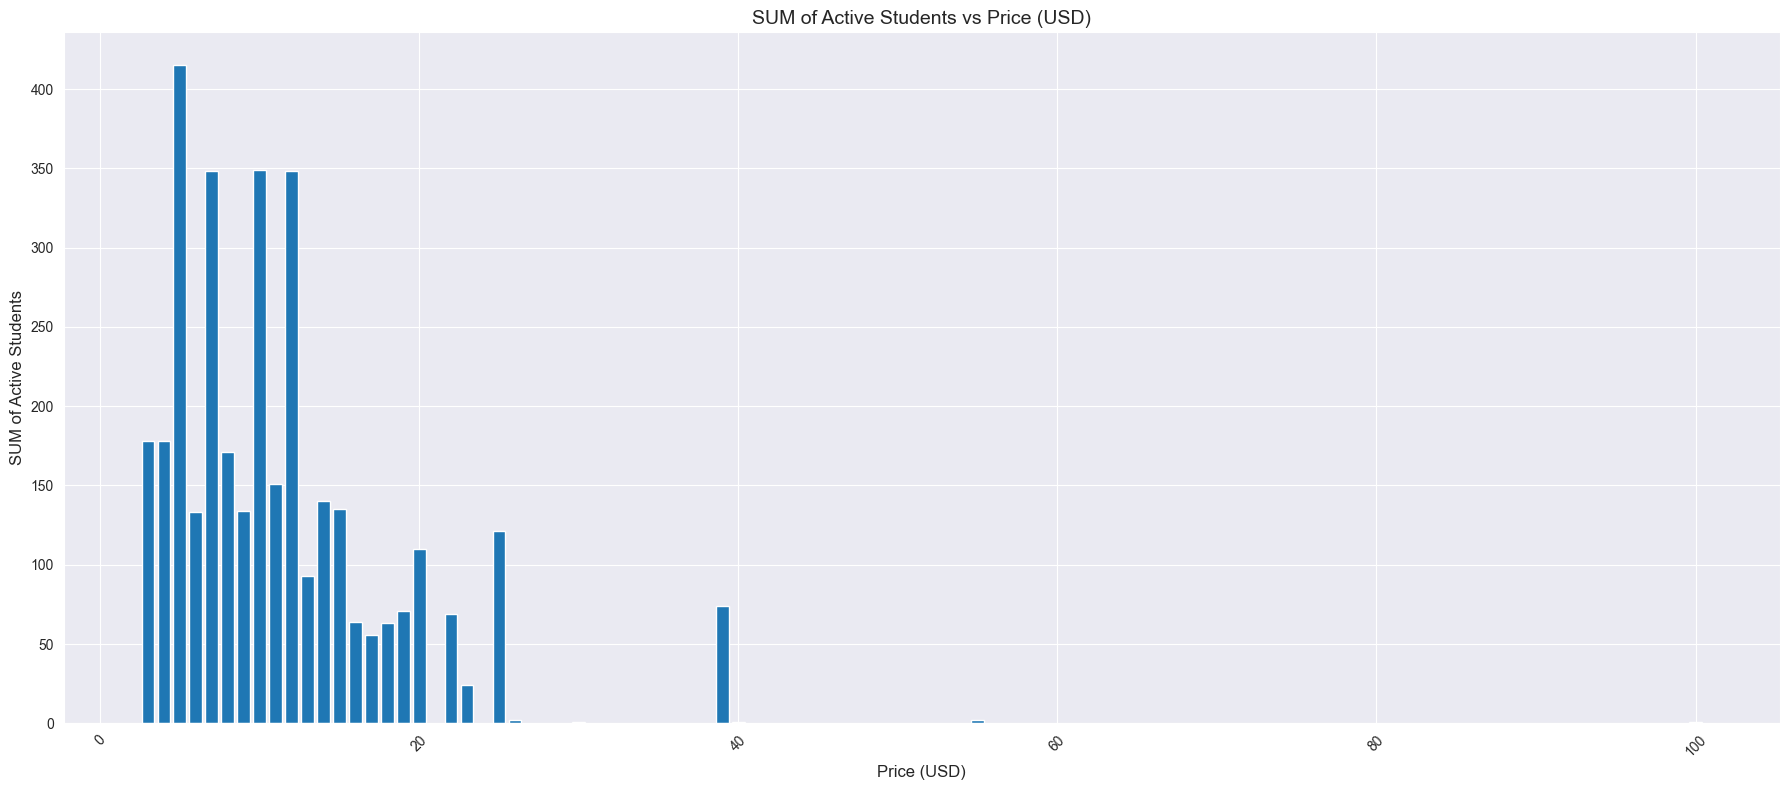

In [37]:
plt.figure(figsize=(18,8))

plt.bar(summary['price'], summary['sum_active_students'])

plt.xlabel("Price (USD)", fontsize=12)
plt.ylabel("SUM of Active Students", fontsize=12)
plt.title("SUM of Active Students vs Price (USD)", fontsize=14)

plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("active_students_vs_price_urdu.png", dpi=300, bbox_inches="tight")
plt.show()


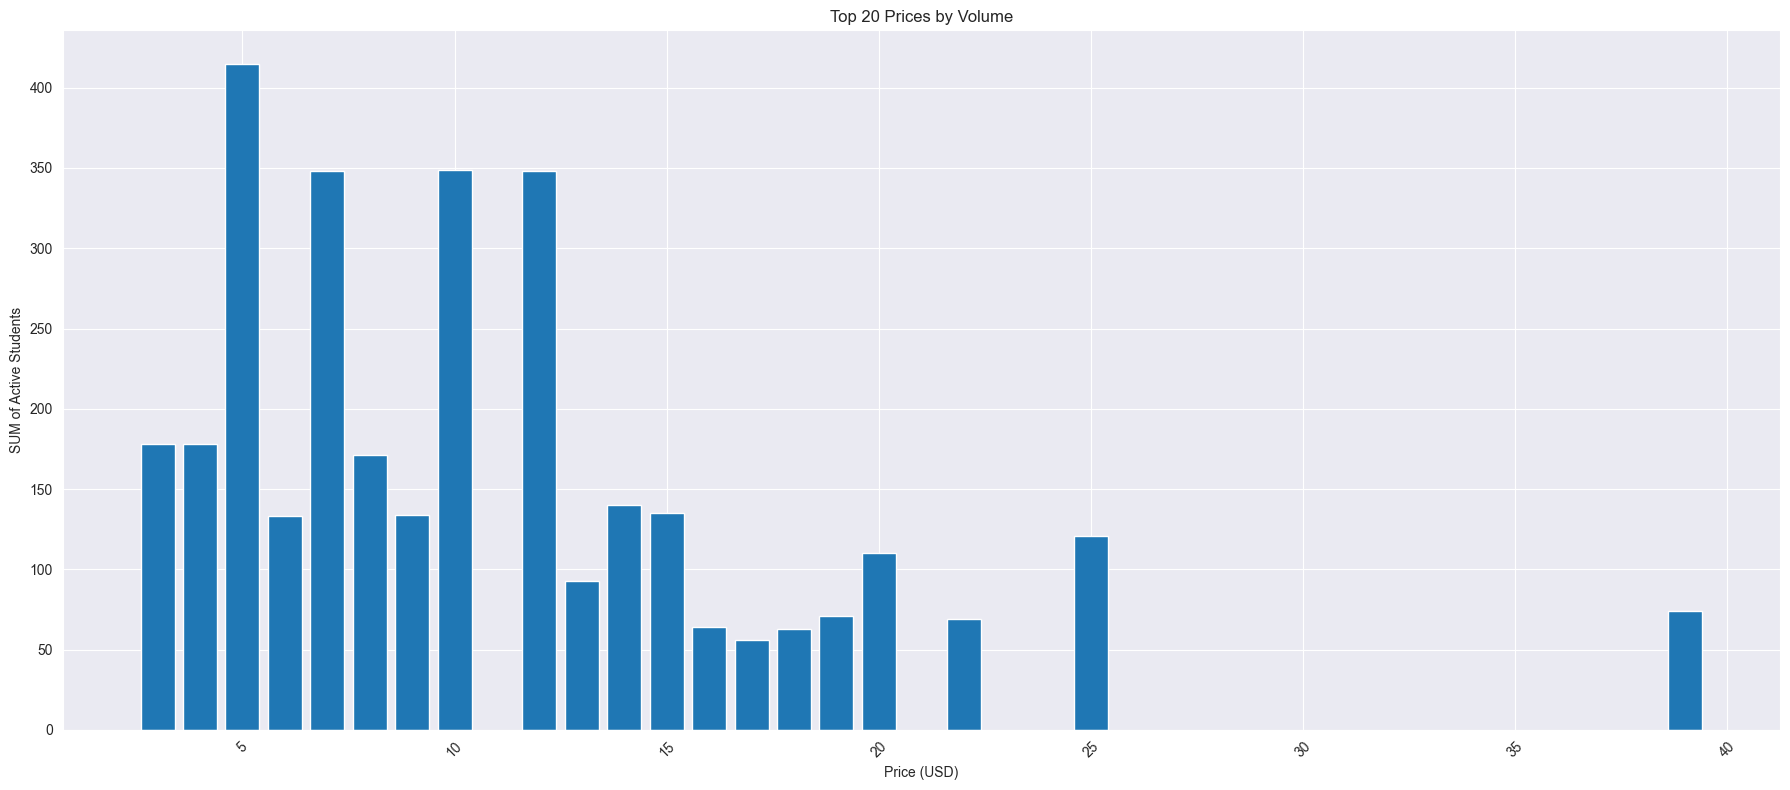

In [38]:
# Show only top 20 prices by lesson volume
top_prices = summary.sort_values('sum_lessons', ascending=False).head(20)

plt.figure(figsize=(18,8))
plt.bar(top_prices['price'], top_prices['sum_active_students'])

plt.xlabel("Price (USD)")
plt.ylabel("SUM of Active Students")
plt.title("Top 20 Prices by Volume")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


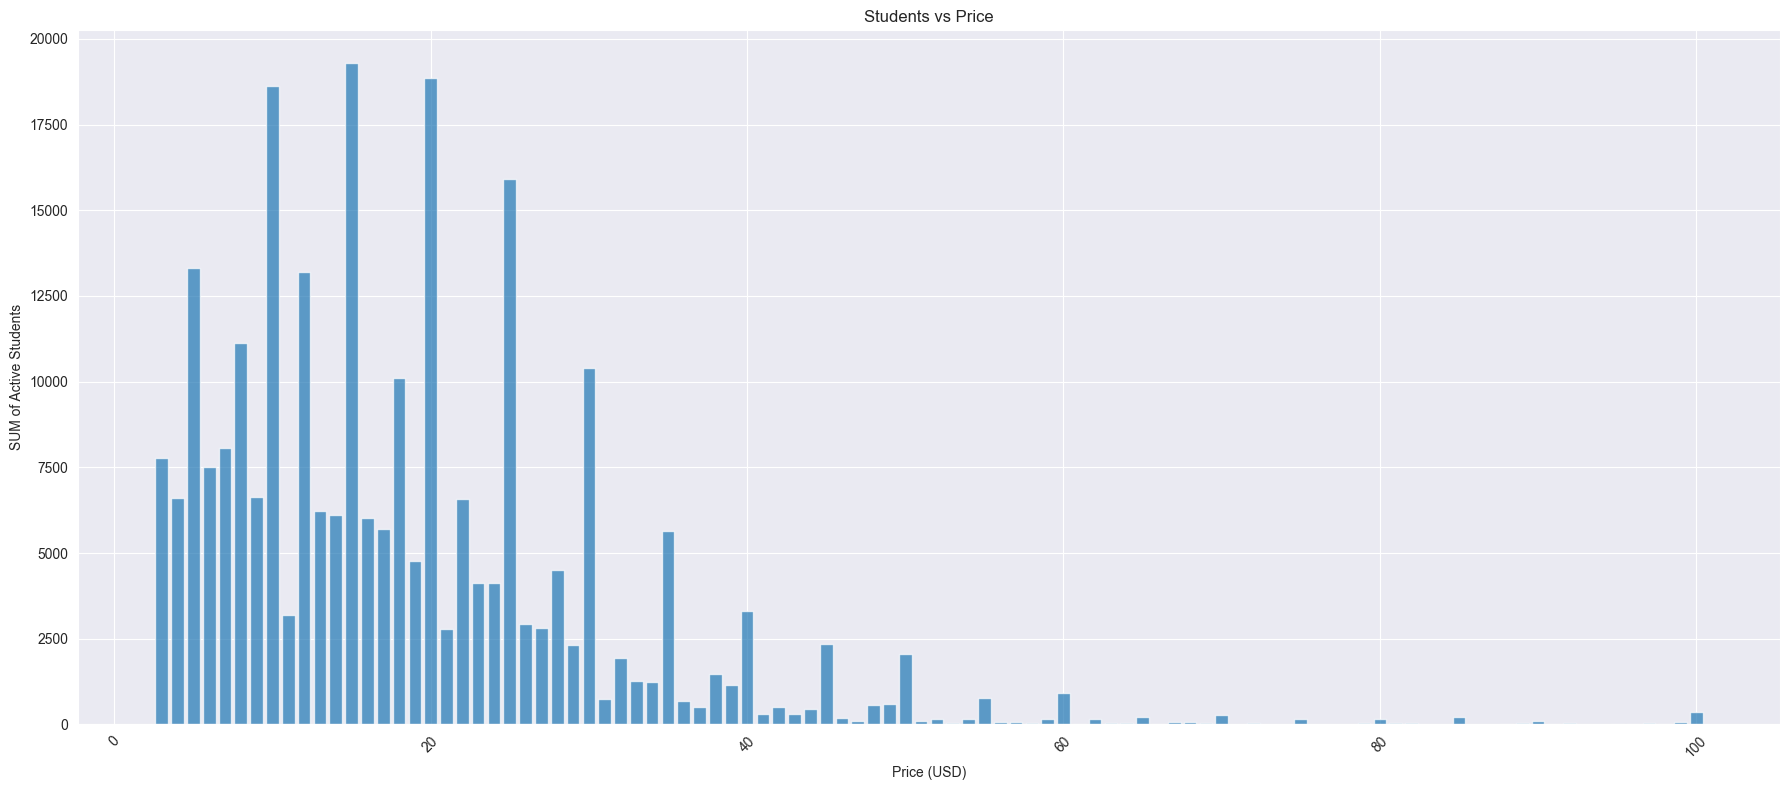

In [36]:
fig, ax1 = plt.subplots(figsize=(18,8))

ax1.bar(summary['price'], summary['sum_active_students'], alpha=0.7)
ax1.set_xlabel("Price (USD)")
ax1.set_ylabel("SUM of Active Students")

plt.xticks(rotation=45)
plt.title("Students vs Price")

plt.tight_layout()
plt.show()


In [54]:
tutor_counts = df.groupby("price")["name"].count().reset_index()
tutor_counts.columns = ["price", "number_of_tutors"]


In [55]:
tutor_counts = df["price"].value_counts().sort_index().reset_index()
tutor_counts.columns = ["price", "number_of_tutors"]


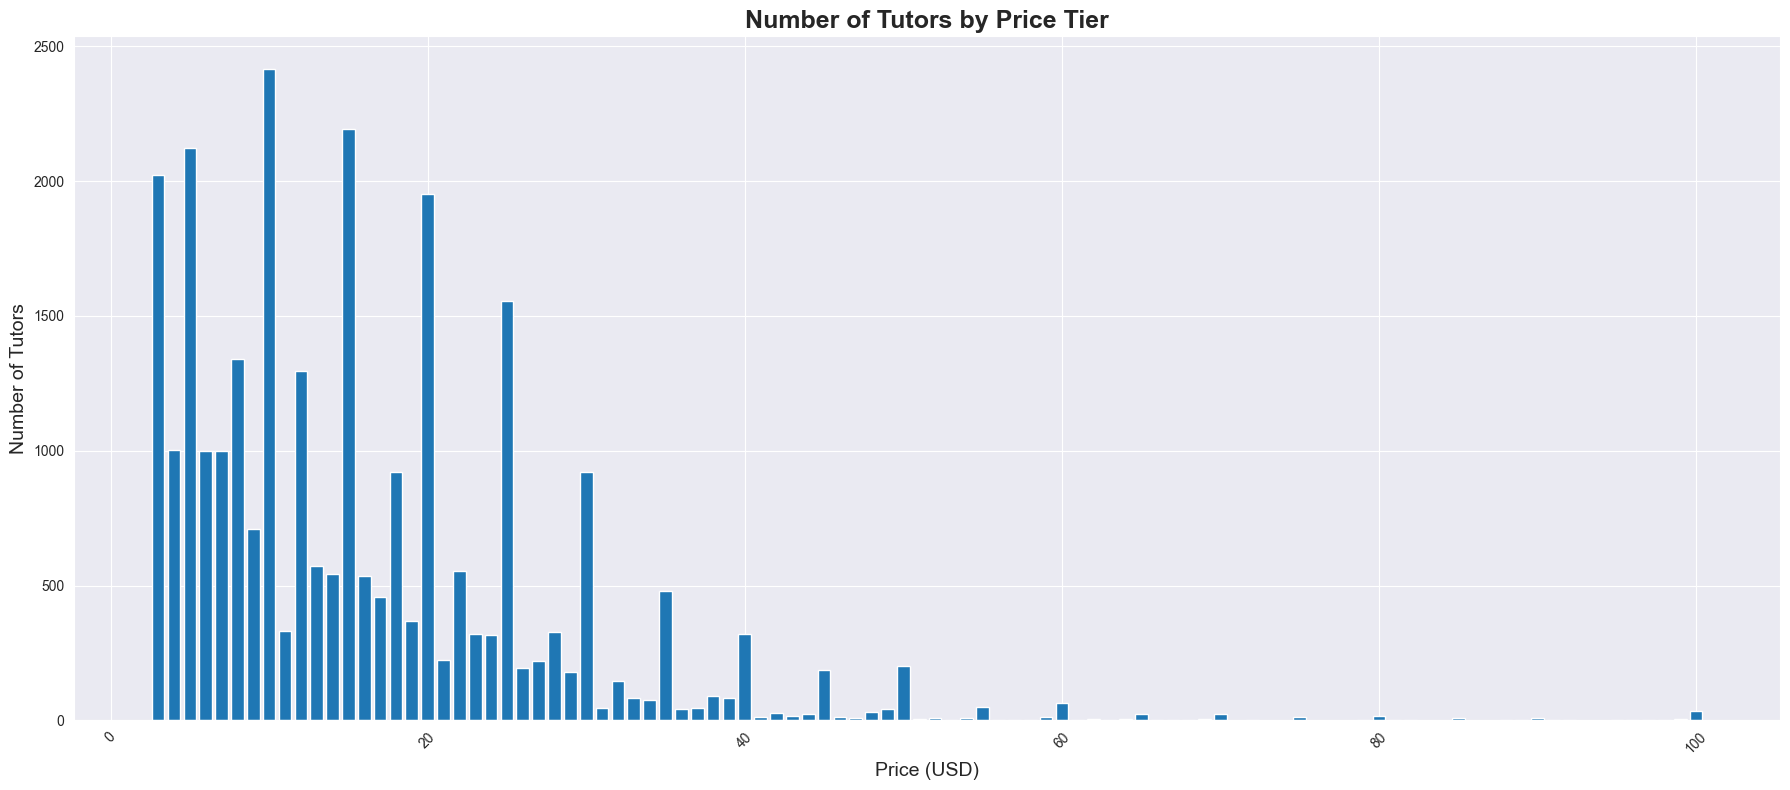

In [56]:
plt.figure(figsize=(18,8))

plt.bar(tutor_counts["price"], tutor_counts["number_of_tutors"])

plt.xlabel("Price (USD)", fontsize=14)
plt.ylabel("Number of Tutors", fontsize=14)
plt.title("Number of Tutors by Price Tier", fontsize=18, fontweight='bold')

plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("tutors_by_price.png", dpi=300, bbox_inches="tight")
plt.show()


<BarContainer object of 86 artists>

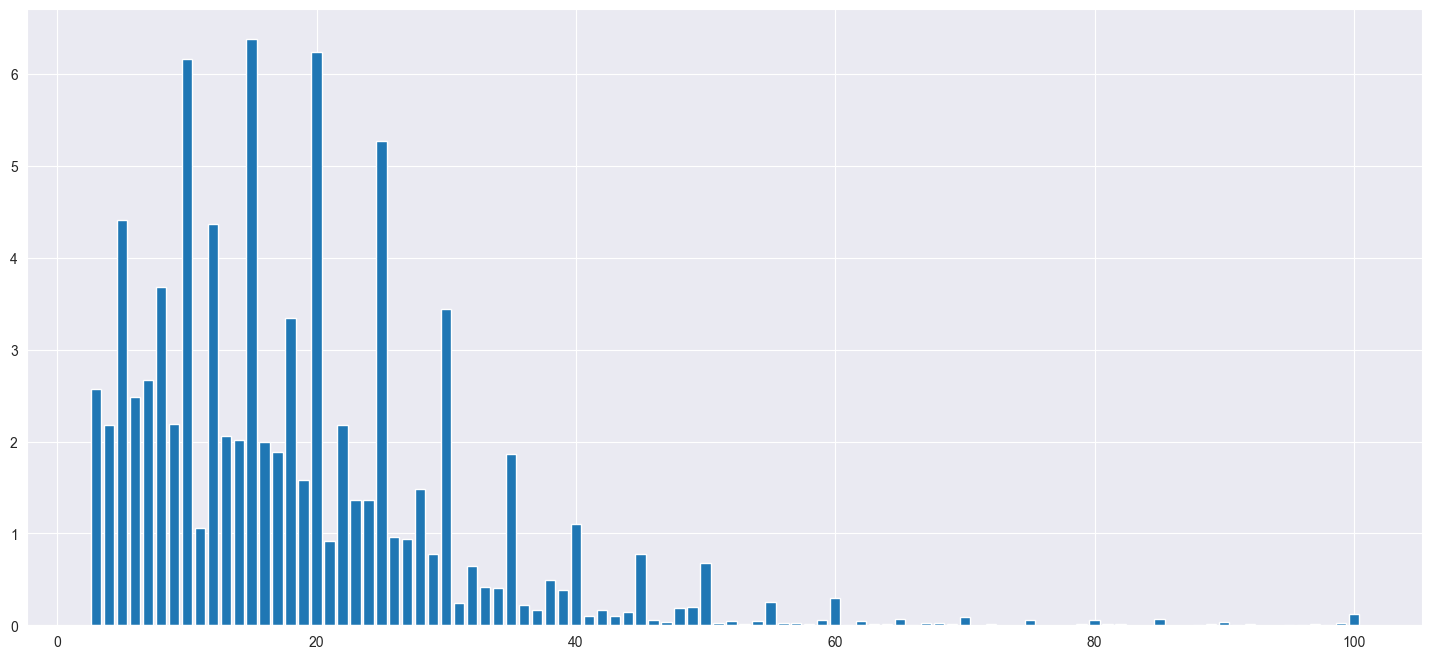

In [57]:
plt.figure(figsize=(18,8))

plt.bar(summary["price"], summary["sum_active_students"] / summary["sum_active_students"].mean())  # ignore this line if not needed


In [61]:
bins = [0, 5, 10, 15, 20, 25, 30, 100]
labels = ["$0–5", "$6–10", "$11–15", "$16–20", "$21–25", "$26–30", "$30+"]

df["price_range"] = pd.cut(df["price"], bins=bins, labels=labels, right=True)


In [62]:
range_counts = df["price_range"].value_counts().sort_index()
range_counts


price_range
$0–5      5147
$6–10     6463
$11–15    4939
$16–20    4237
$21–25    2967
$26–30    1844
$30+      2306
Name: count, dtype: int64

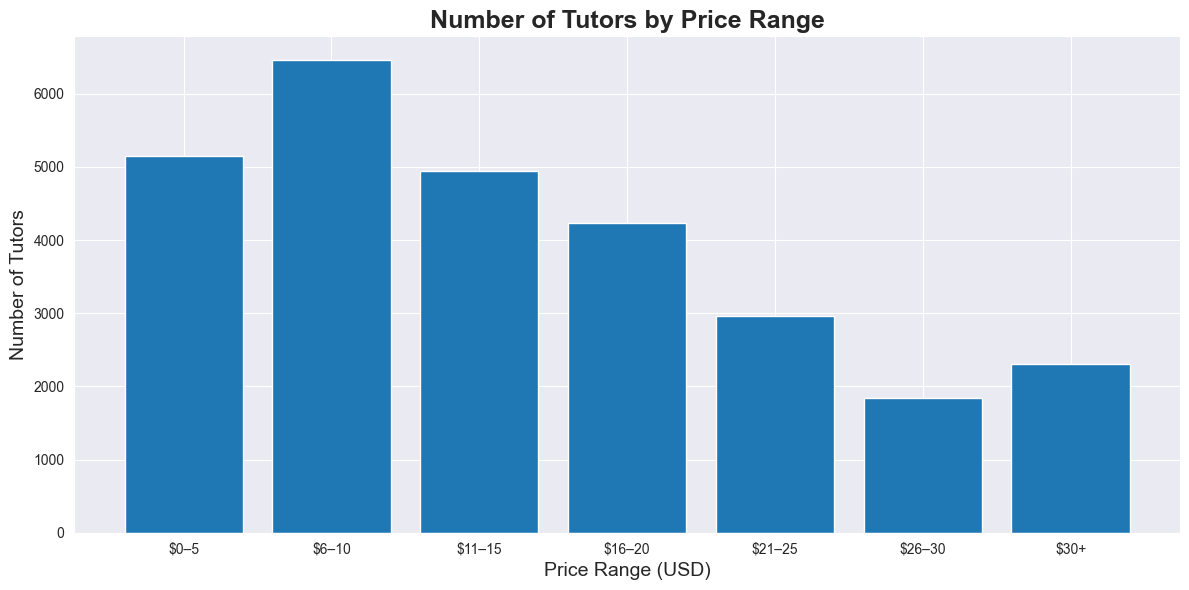

In [63]:
plt.figure(figsize=(12,6))

plt.bar(range_counts.index.astype(str), range_counts.values)

plt.xlabel("Price Range (USD)", fontsize=14)
plt.ylabel("Number of Tutors", fontsize=14)
plt.title("Number of Tutors by Price Range", fontsize=18, fontweight='bold')

plt.tight_layout()
plt.savefig("tutors_by_price_range.png", dpi=300, bbox_inches="tight")
plt.show()


In [64]:
tutor_counts = df["price"].value_counts().sort_index()
tutor_counts


price
3      2022
4      1003
5      2122
6      1000
7       998
       ... 
96        1
97        3
98        1
99        4
100      35
Name: count, Length: 86, dtype: int64

In [65]:
tutor_counts = (
    df["price"]
    .value_counts()
    .sort_index()
    .reset_index()
)

tutor_counts.columns = ["price", "number_of_tutors"]


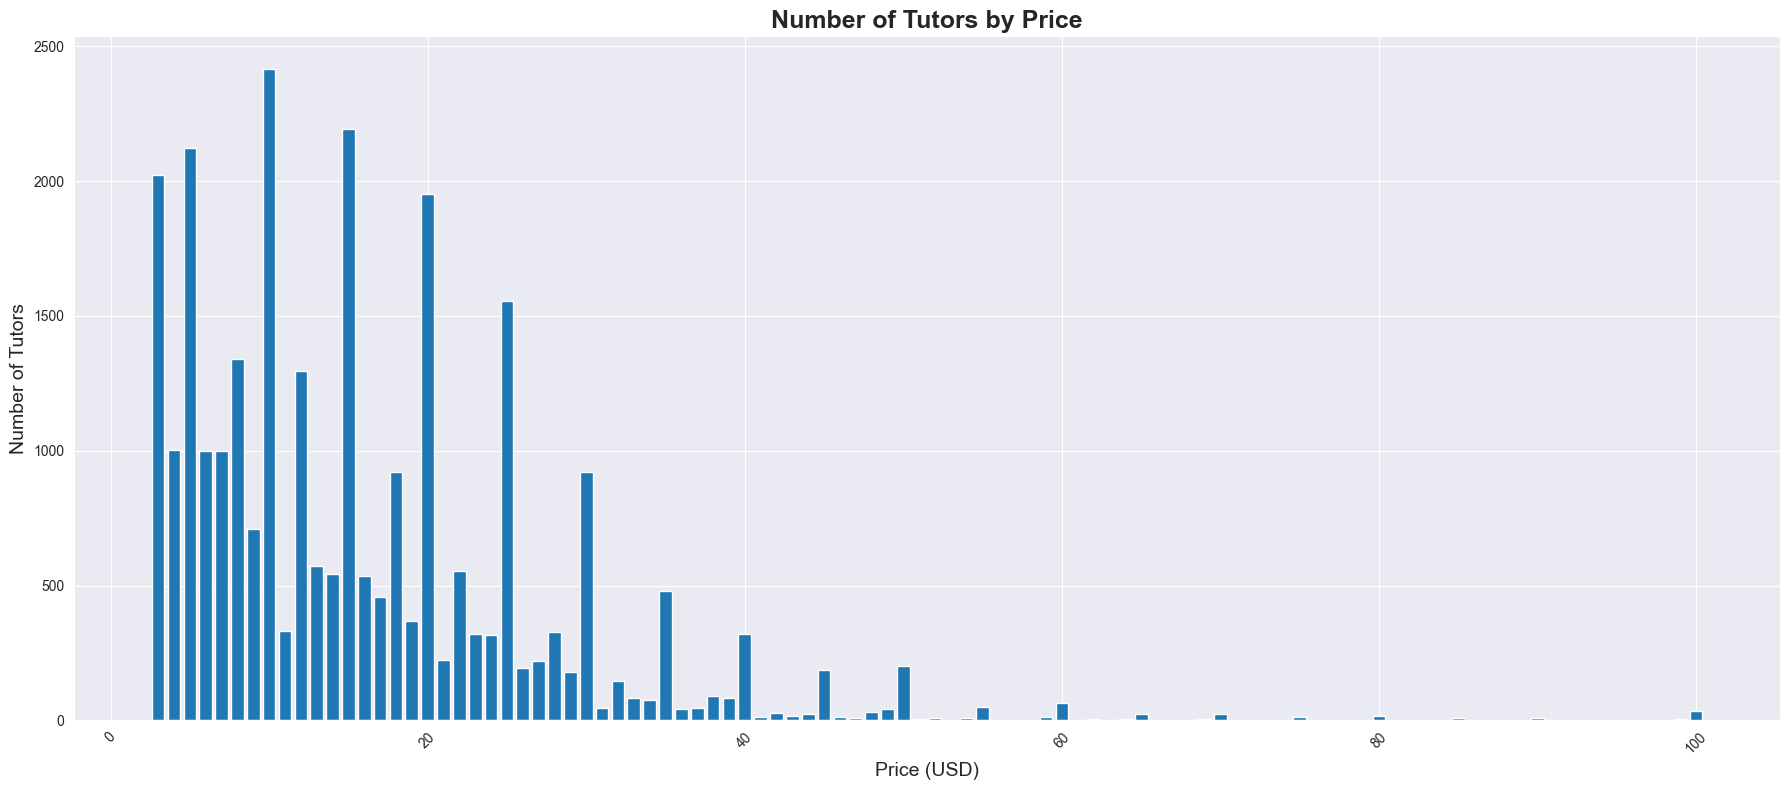

In [66]:
plt.figure(figsize=(18,8))

plt.bar(tutor_counts["price"], tutor_counts["number_of_tutors"])

plt.xlabel("Price (USD)", fontsize=14)
plt.ylabel("Number of Tutors", fontsize=14)
plt.title("Number of Tutors by Price", fontsize=18, fontweight='bold')

plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("tutors_by_price.png", dpi=300, bbox_inches="tight")
plt.show()


<>:14: SyntaxWarning: invalid escape sequence '\d'
<>:14: SyntaxWarning: invalid escape sequence '\d'
C:\Users\shehe\AppData\Local\Temp\ipykernel_13936\3436805331.py:14: SyntaxWarning: invalid escape sequence '\d'
  .str.extract("(\d+)")


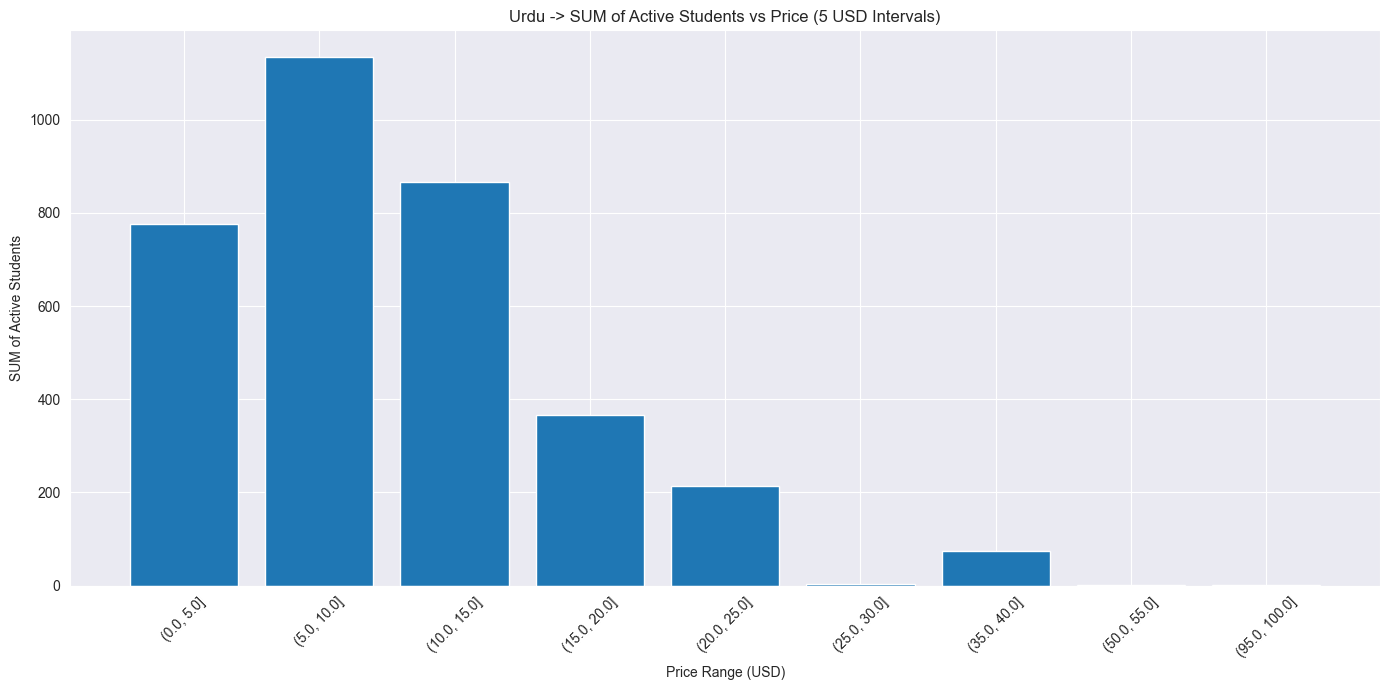

In [80]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load dataset
df = pd.read_csv("preply_tutors.csv")

# ─────────────────────────────────────────
# Clean price column
# ─────────────────────────────────────────
df["price"] = (
    df["price"]
    .str.replace("$", "", regex=False)
    .str.extract("(\d+)")
    .astype(float)
)

# Clean students column
df["students"] = pd.to_numeric(df["students"], errors="coerce")

# Drop missing
df = df.dropna(subset=["price", "students"])

# ─────────────────────────────────────────
# Create 5-dollar bins
# ─────────────────────────────────────────
max_price = df["price"].max()
bins = np.arange(0, max_price + 5, 5)

df["price_range"] = pd.cut(df["price"], bins=bins)

# ─────────────────────────────────────────
# Group by price range and sum students
# ─────────────────────────────────────────
grouped = df.groupby("price_range")["students"].sum().reset_index()

# ─────────────────────────────────────────
# Plot
# ─────────────────────────────────────────
plt.figure(figsize=(14, 7))
plt.bar(grouped["price_range"].astype(str), grouped["students"])

plt.xlabel("Price Range (USD)")
plt.ylabel("SUM of Active Students")
plt.title("English -> SUM of Active Students vs Price (5 USD Intervals)")

plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("english_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

<>:15: SyntaxWarning: invalid escape sequence '\d'
<>:15: SyntaxWarning: invalid escape sequence '\d'
C:\Users\shehe\AppData\Local\Temp\ipykernel_13936\1993286619.py:15: SyntaxWarning: invalid escape sequence '\d'
  .str.extract("(\d+)")


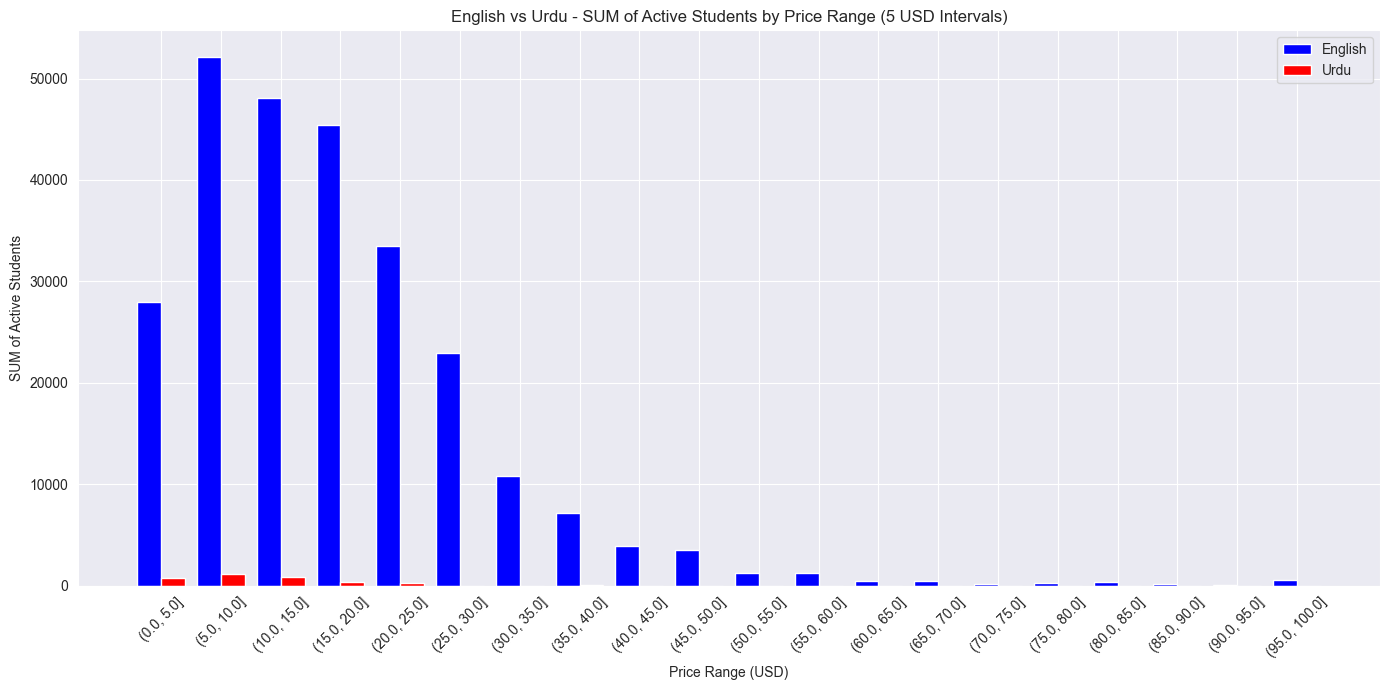

In [82]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ─────────────────────────────────────────
# Load both datasets
# ─────────────────────────────────────────
df_urdu = pd.read_csv("preply_tutors_urdu.csv")
df_eng  = pd.read_csv("preply_tutors.csv")

def prepare_data(df):
    df["price"] = (
        df["price"]
        .str.replace("$", "", regex=False)
        .str.extract("(\d+)")
        .astype(float)
    )
    df["students"] = pd.to_numeric(df["students"], errors="coerce")
    df = df.dropna(subset=["price", "students"])
    return df

df_urdu = prepare_data(df_urdu)
df_eng  = prepare_data(df_eng)

# ─────────────────────────────────────────
# Create shared bins (important!)
# ─────────────────────────────────────────
max_price = max(df_urdu["price"].max(), df_eng["price"].max())
bins = np.arange(0, max_price + 5, 5)

df_urdu["price_range"] = pd.cut(df_urdu["price"], bins=bins)
df_eng["price_range"]  = pd.cut(df_eng["price"], bins=bins)

# ─────────────────────────────────────────
# Group by bins
# ─────────────────────────────────────────
urdu_grouped = df_urdu.groupby("price_range")["students"].sum()
eng_grouped  = df_eng.groupby("price_range")["students"].sum()

# Align indexes
urdu_grouped = urdu_grouped.reindex(eng_grouped.index, fill_value=0)
eng_grouped  = eng_grouped.reindex(urdu_grouped.index, fill_value=0)

# ─────────────────────────────────────────
# Plot
# ─────────────────────────────────────────
x = np.arange(len(urdu_grouped.index))
width = 0.4

plt.figure(figsize=(14,7))

plt.bar(x - width/2, eng_grouped.values, width=width, label="English", color="blue")
plt.bar(x + width/2, urdu_grouped.values, width=width, label="Urdu", color="red")

plt.xticks(x, urdu_grouped.index.astype(str), rotation=45)
plt.xlabel("Price Range (USD)")
plt.ylabel("SUM of Active Students")
plt.title("English vs Urdu - SUM of Active Students by Price Range (5 USD Intervals)")
plt.legend()

plt.tight_layout()
plt.savefig("english x urdu.png", dpi=300, bbox_inches="tight")
plt.show()

<>:15: SyntaxWarning: invalid escape sequence '\d'
<>:15: SyntaxWarning: invalid escape sequence '\d'
C:\Users\shehe\AppData\Local\Temp\ipykernel_13936\1063536415.py:15: SyntaxWarning: invalid escape sequence '\d'
  .str.extract("(\d+)")


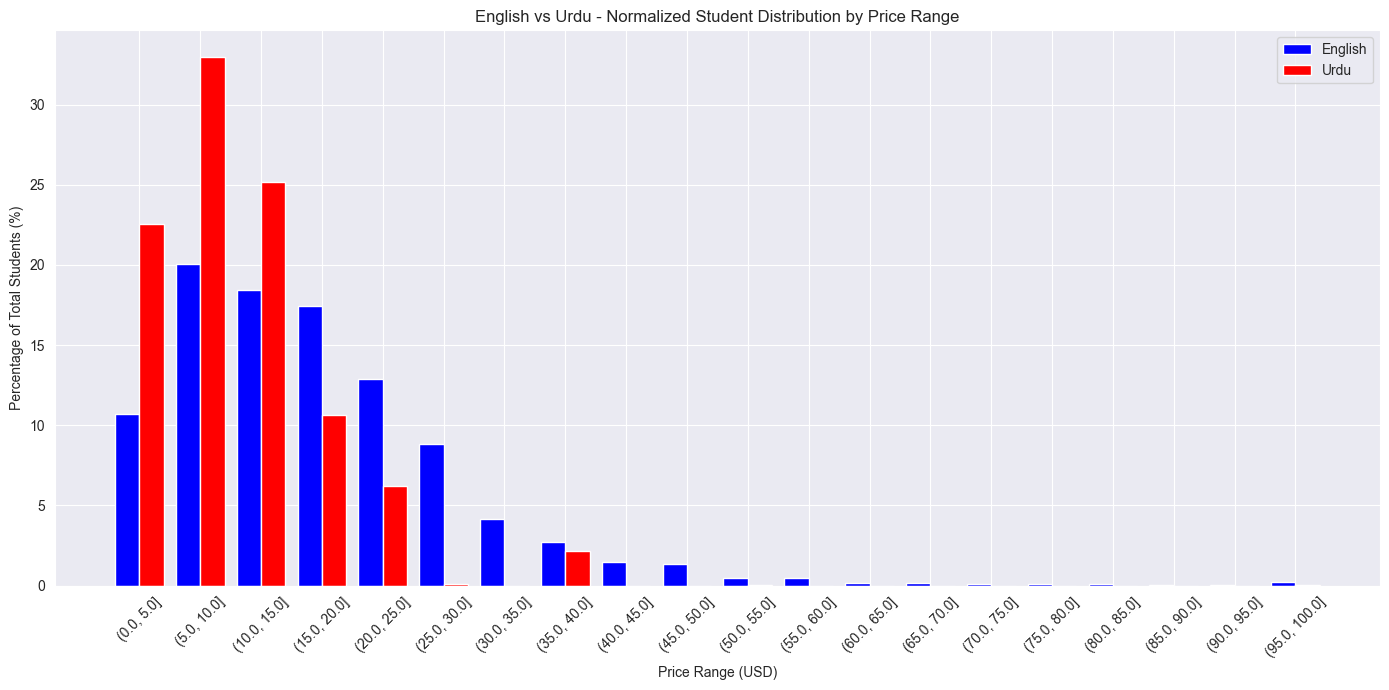

In [84]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ─────────────────────────────────────────
# Load both datasets
# ─────────────────────────────────────────
df_urdu = pd.read_csv("preply_tutors_urdu.csv")
df_eng  = pd.read_csv("preply_tutors.csv")

def prepare_data(df):
    df["price"] = (
        df["price"]
        .str.replace("$", "", regex=False)
        .str.extract("(\d+)")
        .astype(float)
    )
    df["students"] = pd.to_numeric(df["students"], errors="coerce")
    df = df.dropna(subset=["price", "students"])
    return df

df_urdu = prepare_data(df_urdu)
df_eng  = prepare_data(df_eng)

# ─────────────────────────────────────────
# Create shared bins (important!)
# ─────────────────────────────────────────
max_price = max(df_urdu["price"].max(), df_eng["price"].max())
bins = np.arange(0, max_price + 5, 5)

df_urdu["price_range"] = pd.cut(df_urdu["price"], bins=bins)
df_eng["price_range"]  = pd.cut(df_eng["price"], bins=bins)

# ─────────────────────────────────────────
# Group by bins
# ─────────────────────────────────────────
urdu_grouped = df_urdu.groupby("price_range")["students"].sum()
eng_grouped  = df_eng.groupby("price_range")["students"].sum()

# Align indexes
urdu_grouped = urdu_grouped.reindex(eng_grouped.index, fill_value=0)
eng_grouped  = eng_grouped.reindex(urdu_grouped.index, fill_value=0)

# ─────────────────────────────────────────
# Plot
# ─────────────────────────────────────────
urdu_percent = (urdu_grouped / urdu_grouped.sum()) * 100
eng_percent  = (eng_grouped / eng_grouped.sum()) * 100

x = np.arange(len(urdu_percent.index))
width = 0.4

plt.figure(figsize=(14,7))

plt.bar(x - width/2, eng_percent.values, width=width, label="English", color="blue")
plt.bar(x + width/2, urdu_percent.values, width=width, label="Urdu", color="red")

plt.xticks(x, urdu_percent.index.astype(str), rotation=45)
plt.xlabel("Price Range (USD)")
plt.ylabel("Percentage of Total Students (%)")
plt.title("English vs Urdu - Normalized Student Distribution by Price Range")
plt.legend()

plt.tight_layout()
plt.savefig("english x urdu normalized.png", dpi=300, bbox_inches="tight")
plt.show()

In [88]:
# ─────────────────────────────────────────
# Load dataset
# ─────────────────────────────────────────
df = pd.read_csv("preply_tutors_hindi.csv")  # change to urdu if needed

# ─────────────────────────────────────────
# Clean price column
# ─────────────────────────────────────────
df["price"] = (
    df["price"]
    .str.replace("$", "", regex=False)
    .str.extract("(\d+)")
    .astype(float)
)

# Clean lessons column
df["lessons"] = pd.to_numeric(df["lessons"], errors="coerce")

# Drop missing values
df = df.dropna(subset=["price", "lessons"])

# ─────────────────────────────────────────
# Calculate revenue
# ─────────────────────────────────────────
df["revenue"] = df["price"] * df["lessons"]

# ─────────────────────────────────────────
# Keep only required columns
# ─────────────────────────────────────────
final_df = df[["price", "lessons", "revenue"]]

# ─────────────────────────────────────────
# Save to new CSV
# ─────────────────────────────────────────
final_df.to_csv("hindi_preply_revenue.csv", index=False)

print("New CSV created: preply_revenue.csv")

New CSV created: preply_revenue.csv


<>:12: SyntaxWarning: invalid escape sequence '\d'
<>:12: SyntaxWarning: invalid escape sequence '\d'
C:\Users\shehe\AppData\Local\Temp\ipykernel_13936\4143273982.py:12: SyntaxWarning: invalid escape sequence '\d'
  .str.extract("(\d+)")


<>:13: SyntaxWarning: invalid escape sequence '\d'
<>:13: SyntaxWarning: invalid escape sequence '\d'
C:\Users\shehe\AppData\Local\Temp\ipykernel_13936\868791567.py:13: SyntaxWarning: invalid escape sequence '\d'
  .str.extract("(\d+)")


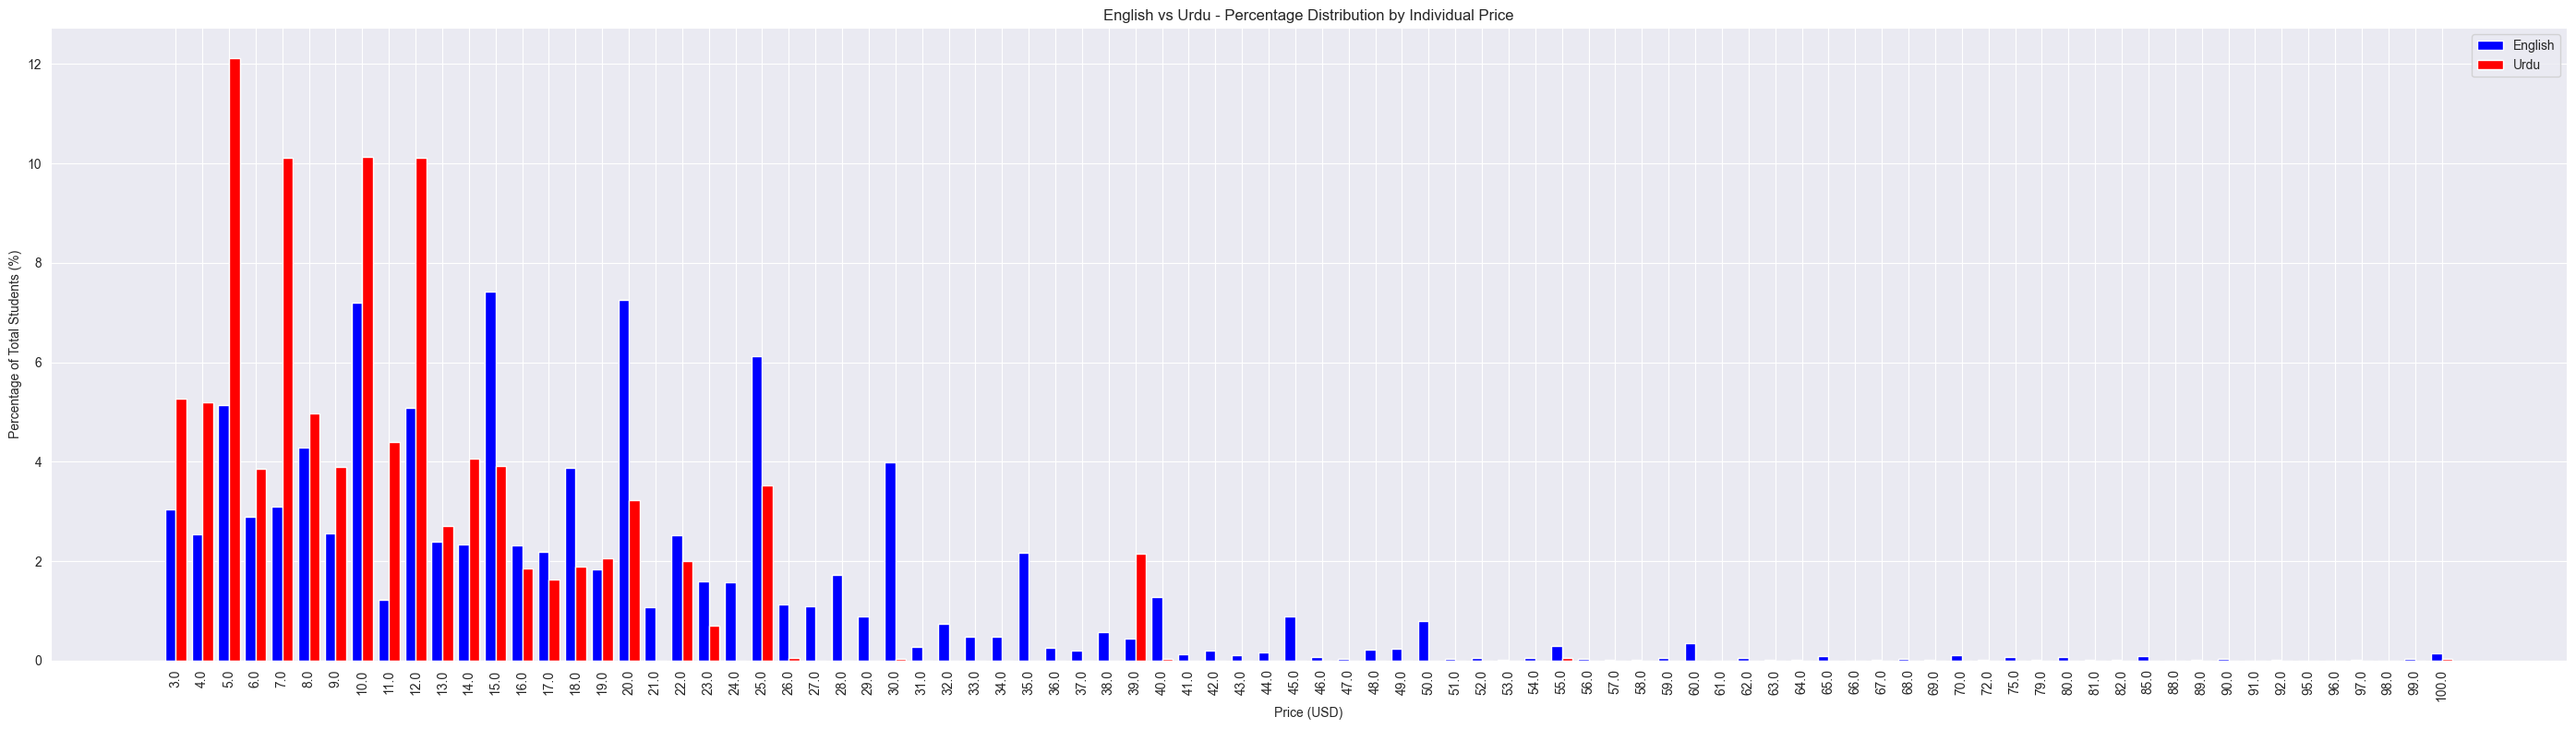

In [95]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load datasets
df_eng  = pd.read_csv("preply_tutors.csv")
df_urdu = pd.read_csv("preply_tutors_urdu.csv")

def prepare(df):
    df["price"] = (
        df["price"]
        .str.replace("$", "", regex=False)
        .str.extract("(\d+)")
        .astype(float)
    )
    df["students"] = pd.to_numeric(df["students"], errors="coerce")
    df = df.dropna(subset=["price", "students"])
    return df

df_eng = prepare(df_eng)
df_urdu = prepare(df_urdu)

# Group by exact price
eng_grouped  = df_eng.groupby("price")["students"].sum()
urdu_grouped = df_urdu.groupby("price")["students"].sum()

# Normalize to percentage
eng_percent  = (eng_grouped / eng_grouped.sum()) * 100
urdu_percent = (urdu_grouped / urdu_grouped.sum()) * 100

# Align price indexes
all_prices = sorted(set(eng_percent.index).union(set(urdu_percent.index)))
eng_percent  = eng_percent.reindex(all_prices, fill_value=0)
urdu_percent = urdu_percent.reindex(all_prices, fill_value=0)

# Plot bar chart
x = np.arange(len(all_prices))
width = 0.4

plt.figure(figsize=(28, 8))  # very wide

x = np.arange(len(all_prices))
width = 0.4

plt.bar(x - width/2, eng_percent.values, width=width, label="English", color="blue")
plt.bar(x + width/2, urdu_percent.values, width=width, label="Urdu", color="red")

# Show every 3rd price label only (reduces noise)
tick_spacing = 1
plt.xticks(x[::tick_spacing], all_prices[::tick_spacing], rotation=90)

plt.xlabel("Price (USD)")
plt.ylabel("Percentage of Total Students (%)")
plt.title("English vs Urdu - Percentage Distribution by Individual Price")
plt.legend()

plt.tight_layout()

# Save high resolution
plt.savefig("english_vs_urdu_price_distribution.png", dpi=300, bbox_inches="tight")

plt.show()